In [39]:
# Step 1: Install Required Library
# This installs the SHAP library used for model explainability.

!pip install shap -q

In [40]:
# Step 2: Import Required Libraries
# Import libraries for data analysis, visualization, machine learning, and explainable AI.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings

warnings.filterwarnings("ignore")

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

plt.style.use("ggplot")

In [42]:
# Step 3: Load the Dataset
# Read the uploaded CSV file into a Pandas DataFrame.

df = pd.read_csv("/content/WBCD_prognosis.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,R,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,R,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,R,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,R,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,R,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [43]:
# Step 4: Explore the Dataset
# Display dataset information including data types and non-null values.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [44]:
# Display descriptive statistics for all numerical features.

df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


In [45]:
# Check the distribution of diagnosis classes.

df["diagnosis"].value_counts()

,count
diagnosis,
N,357
R,212


In [46]:
# Step 5: Data Cleaning
# Remove the ID column because it is not useful for prediction.

df = df.drop("id", axis=1)

# Check for missing values.

print(df.isnull().sum())
print("Total Missing Values:", df.isnull().sum().sum())

# Check for duplicate records.

print("Duplicate Rows:", df.duplicated().sum())

# Remove duplicate records if they exist.

df = df.drop_duplicates()

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64
Total Missing Values: 0
Duplicate Rows: 0


In [47]:
# Step 6: Encode the Target Variable
# Convert diagnosis labels into binary numerical values.

df["diagnosis"] = df["diagnosis"].map({"R":1, "N":0})

df["diagnosis"].value_counts()

,count
diagnosis,
0,357
1,212


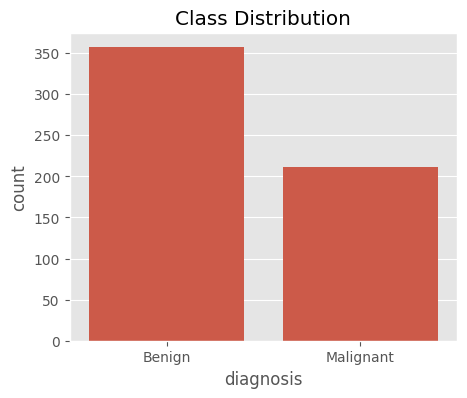

In [48]:
# Step 7: Exploratory Data Analysis (EDA)
# Step 7.1: Visualize Class Distribution
# Display the number of benign and malignant cases.

plt.figure(figsize=(5,4))

sns.countplot(x=df["diagnosis"])

plt.xticks([0,1],["Benign","Malignant"])
plt.title("Class Distribution")

plt.show()

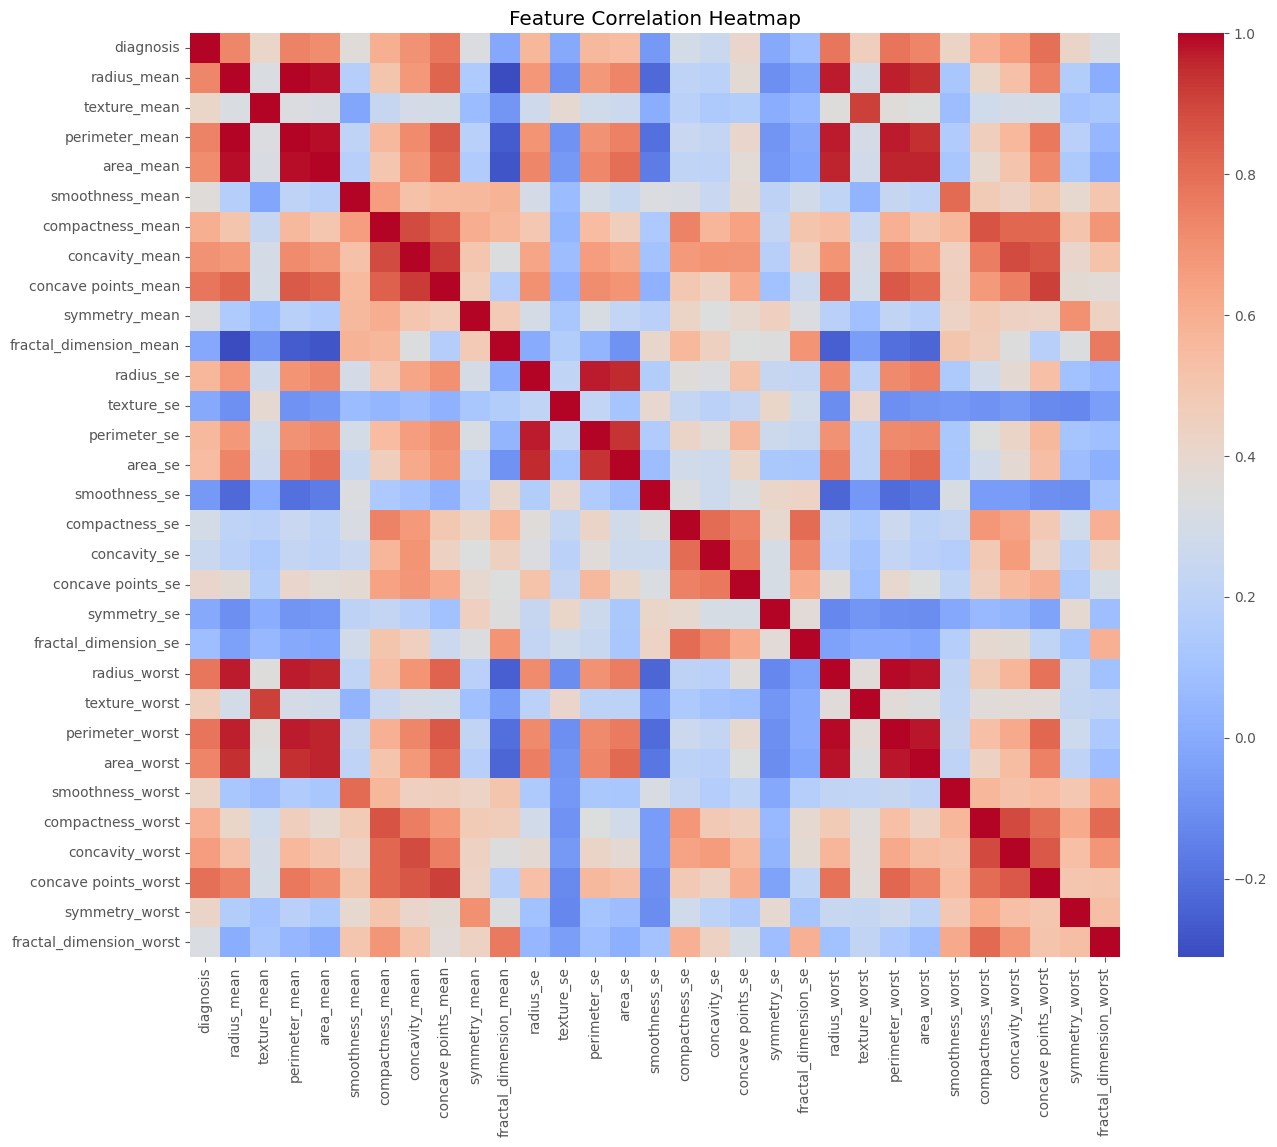

In [49]:
# Step 7.2: Correlation Heatmap
# Visualize relationships between numerical features.

plt.figure(figsize=(15,12))

sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Feature Correlation Heatmap")

plt.show()

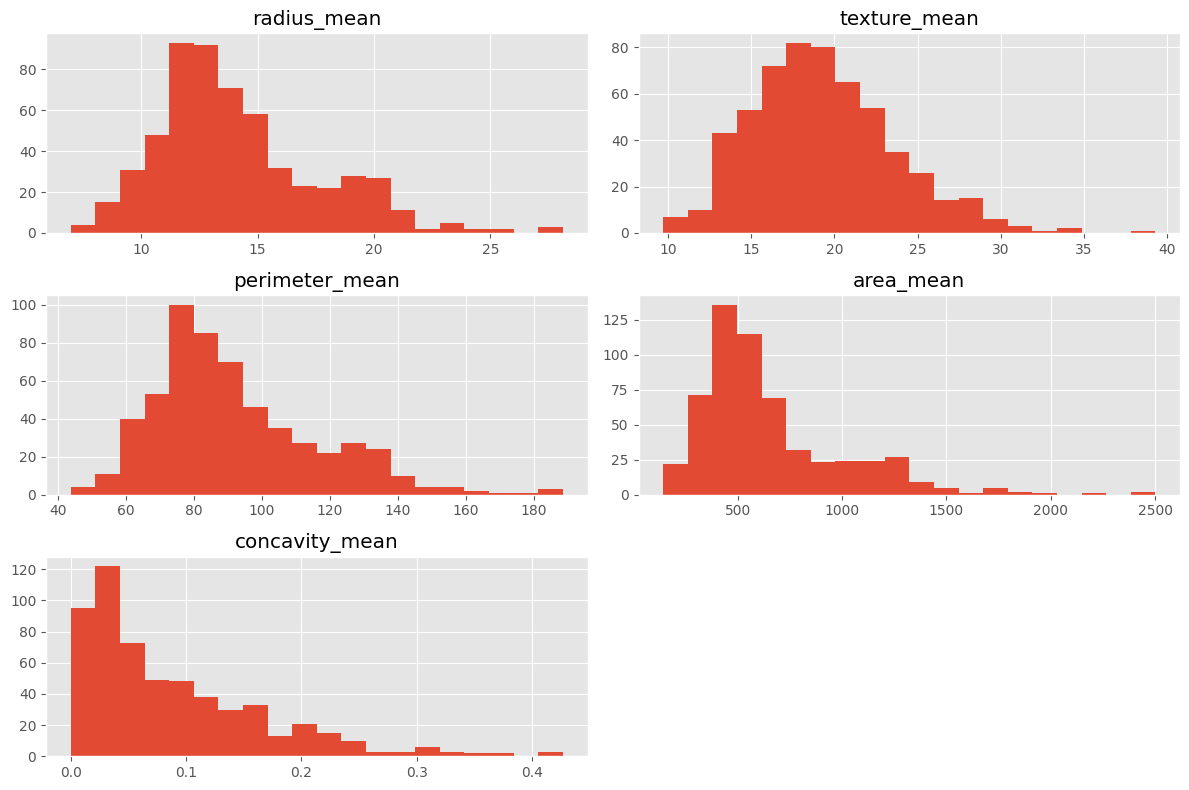

In [50]:
# Step 7.3: Feature Distributions
# Display histograms for selected important features.

features = [
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "concavity_mean"
]

df[features].hist(figsize=(12,8), bins=20)

plt.tight_layout()
plt.show()

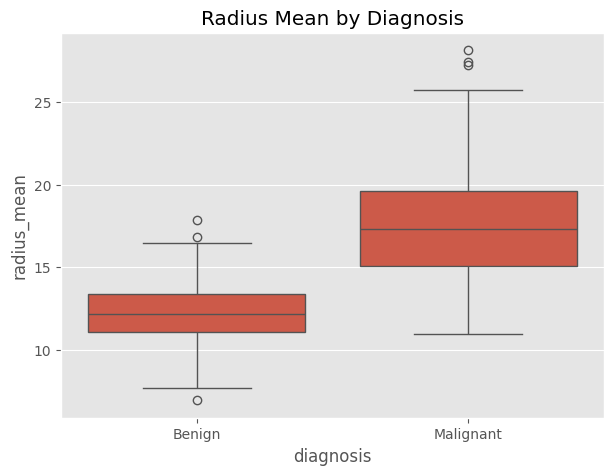

In [51]:
# Step 7.4: Boxplot Analysis
# Compare Radius Mean between benign and malignant cases.

plt.figure(figsize=(7,5))

sns.boxplot(
    x=df["diagnosis"],
    y=df["radius_mean"]
)

plt.xticks([0,1],["Benign","Malignant"])
plt.title("Radius Mean by Diagnosis")

plt.show()

In [52]:
# Step 8: Prepare Features and Target Variable
# Separate independent variables (X) and the target variable (y).

X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

In [53]:
# Step 9: Split the Dataset
# Create training and testing datasets using stratified sampling.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (455, 30)
Testing Shape: (114, 30)


In [54]:
# Step 10: Standardize Features
# Standardize feature values for Logistic Regression.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [55]:
#Step 11: Train Machine Learning Models
# Step 11.1: Train Logistic Regression
# Train Logistic Regression using standardized features.

lr = LogisticRegression(random_state=42)

lr.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [56]:
# Step 11.2: Train Decision Tree
# Train the Decision Tree classifier.

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [57]:
# Step 11.3: Train Random Forest
# Train the proposed Random Forest model.

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [58]:
# Step 12: Create Model Evaluation Function
# Calculate Accuracy, Precision, Sensitivity, Specificity, F1 Score, ROC-AUC, and False Negative Rate.

def evaluate_model(model, X_data, y_true):

    y_pred = model.predict(X_data)
    y_prob = model.predict_proba(X_data)[:,1]

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    specificity = tn/(tn+fp)
    fnr = fn/(fn+tp)

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Sensitivity": recall_score(y_true, y_pred),
        "Specificity": specificity,
        "F1 Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "False Negative Rate": fnr
    }

In [59]:
# Step 13: Compare Model Performance
# Compare Logistic Regression, Decision Tree, and Random Forest.

results = pd.DataFrame({
    "Logistic Regression": evaluate_model(lr, X_test_scaled, y_test),
    "Decision Tree": evaluate_model(dt, X_test, y_test),
    "Random Forest": evaluate_model(rf, X_test, y_test)
}).T

results.round(4)

,Accuracy,Precision,Sensitivity,Specificity,F1 Score,ROC-AUC,False Negative Rate
Logistic Regression,0.9649,0.9750,0.9286,0.9861,0.9512,0.9960,0.0714
Decision Tree,0.9298,0.9048,0.9048,0.9444,0.9048,0.9246,0.0952
Random Forest,0.9649,1.0000,0.9048,1.0000,0.9500,0.9942,0.0952


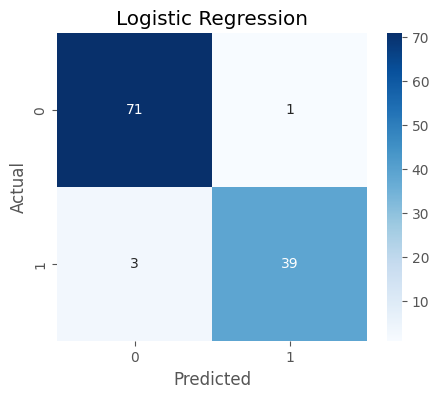

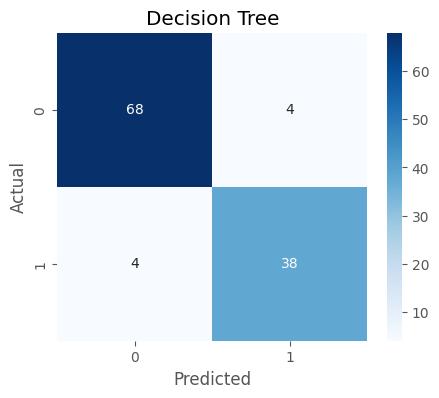

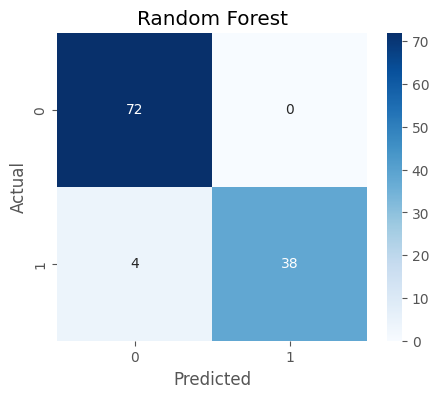

In [61]:
# Step 14: Generate Confusion Matrices
# Display confusion matrices for all trained models.

models = [
    ("Logistic Regression", lr, X_test_scaled),
    ("Decision Tree", dt, X_test),
    ("Random Forest", rf, X_test)
]

for name, model, X_data in models:

    plt.figure(figsize=(5,4))

    cm = confusion_matrix(y_test, model.predict(X_data))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

Logistic Regression
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

Decision Tree
              precision    recall  f1-score   support

           0       0.94      0.94      0.94        72
           1       0.90      0.90      0.90        42

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114

Random Forest
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        72
           1       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97   

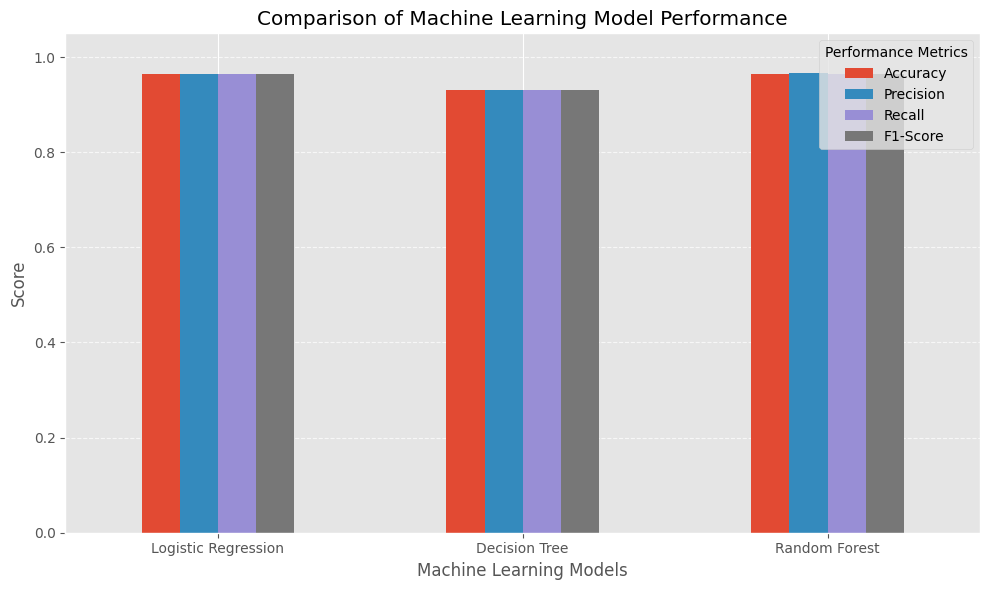

In [72]:
# Step 15: Generate Classification Reports and Visualize Performance
# Display detailed classification reports and create a comparison graph.

import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score

results = []

for name, model, X_data in models:

    print("=" * 50)
    print(name)
    print("=" * 50)

    # Predictions
    y_pred = model.predict(X_data)

    # Classification report
    print(classification_report(y_test, y_pred))

    # Store performance metrics
    report = classification_report(
        y_test,
        y_pred,
        output_dict=True
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": report["weighted avg"]["precision"],
        "Recall": report["weighted avg"]["recall"],
        "F1-Score": report["weighted avg"]["f1-score"]
    })


# Convert results into a DataFrame
results_df = pd.DataFrame(results)

print("\nModel Performance Summary:")
print(results_df)


# Step 15.1: Visualize Model Performance

metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

results_df.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Comparison of Machine Learning Model Performance")
plt.xlabel("Machine Learning Models")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(title="Performance Metrics")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

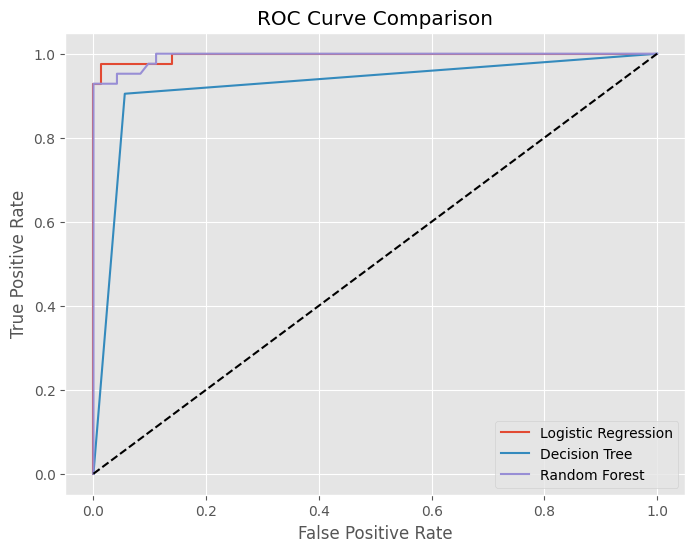

In [63]:
# Step 16: Plot ROC Curves
# Compare ROC curves for all trained models.

plt.figure(figsize=(8,6))

for name, model, X_data in models:

    probs = model.predict_proba(X_data)[:,1]

    fpr, tpr, _ = roc_curve(y_test, probs)

    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

In [64]:
# Step 17: Random Forest Feature Importance
# Identify the most influential features.

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
22,perimeter_worst,0.147912
23,area_worst,0.132269
27,concave points_worst,0.110114
7,concave points_mean,0.088200
20,radius_worst,0.085116
0,radius_mean,0.060554
2,perimeter_mean,0.060465
3,area_mean,0.044701
6,concavity_mean,0.044091
26,concavity_worst,0.032828


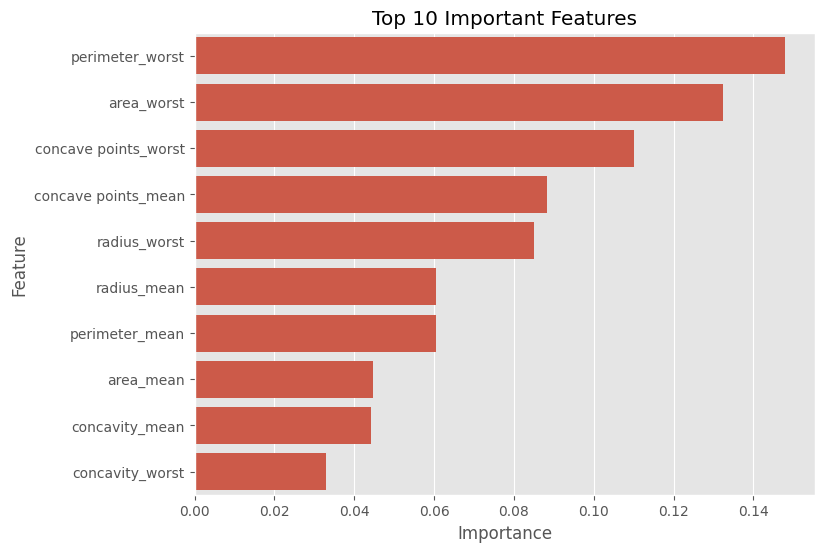

In [65]:
# Step 18: Plot Feature Importance
# Visualize the top 10 important features.

plt.figure(figsize=(8,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.show()

In [66]:
#Step 19: SHAP Explainability
# Step 19.1: Create SHAP Explainer
# Initialize SHAP for the Random Forest model.

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_test)

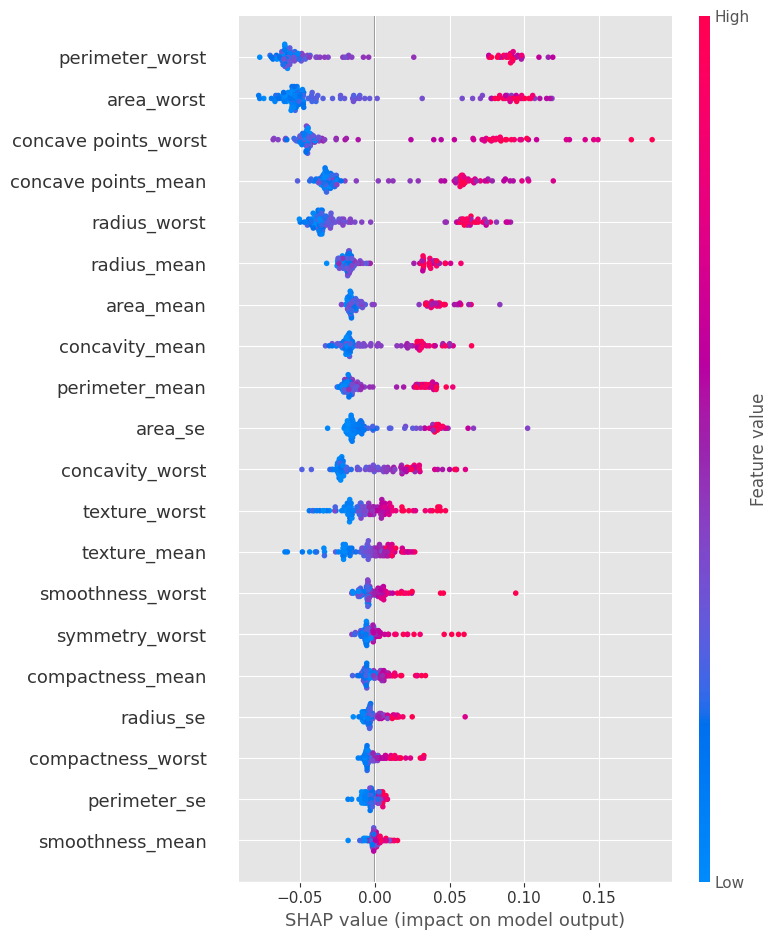

In [67]:
# Step 19.2: SHAP Summary Plot
# Display global feature importance using SHAP.

shap.summary_plot(
    shap_values[:,:,1],
    X_test
)

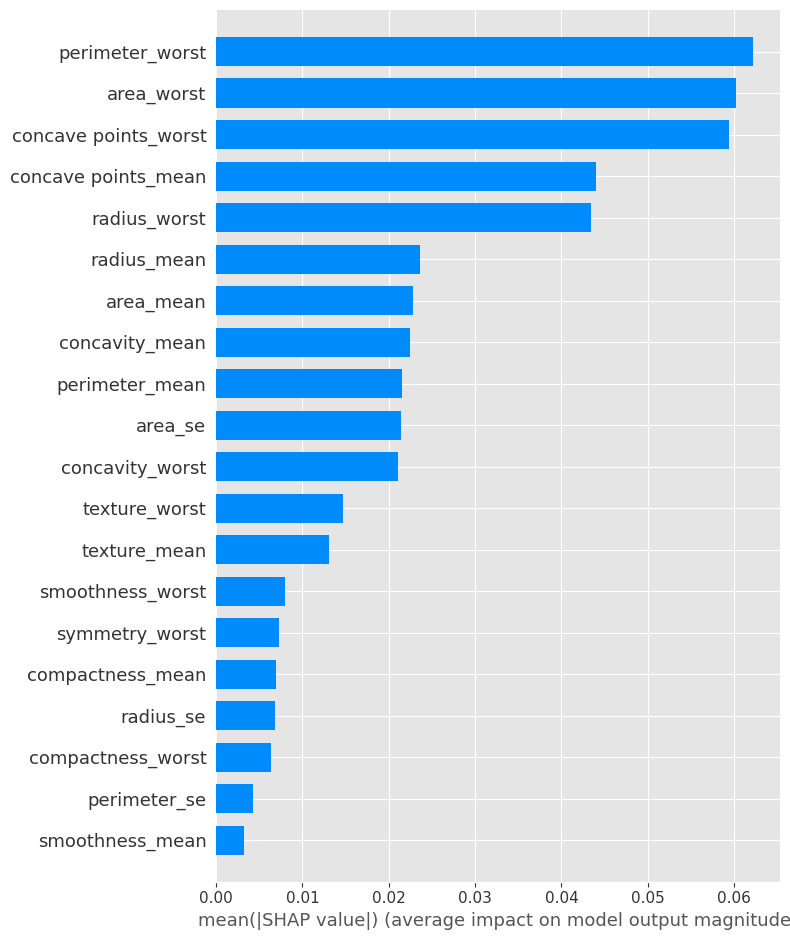

In [68]:
# Step 19.3: SHAP Bar Plot
# Display ranked SHAP feature importance.

shap.summary_plot(
    shap_values[:,:,1],
    X_test,
    plot_type="bar"
)

In [69]:
# Step 19.4: Explain One Individual Prediction
# Visualize SHAP values for one patient.

sample = 0

shap.initjs()

shap.force_plot(
    explainer.expected_value[1],
    shap_values[sample,:,1],
    X_test.iloc[sample]
)

In [70]:
# Step 20: Prediction Confidence
# Display prediction confidence for each test sample.

probabilities = rf.predict_proba(X_test)

prediction_table = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": rf.predict(X_test),
    "Confidence": probabilities.max(axis=1)
})

prediction_table.head(10)

,Actual,Predicted,Confidence
0,0,0,0.985
1,1,1,1.000
2,0,0,0.670
3,1,1,0.585
4,0,0,0.895
5,0,0,0.910
6,1,1,0.610
7,0,0,0.830
8,0,0,1.000
9,0,0,0.990


In [71]:
# Step 21: Save Results
# Save evaluation metrics and feature importance as CSV files.

results.to_csv("Model_Evaluation_Results.csv", index=True)
importance.to_csv("Feature_Importance.csv", index=False)